## Fast API Learning Book

The performance is better than other tool chains: Django Flask

Also the Fast API can be learn quickly while creating the API interfaces

While the FastAPI been deployed, it will automatic create a interactive doc for finding and testing API

## 1.Start Using the Vscode

Need to create a virtual environment

In command line:

`python -m venv [Name]`

To install the fast API: 

`pip install fastapi[standard]`

## 2. The Structure and the main process of FastAPI

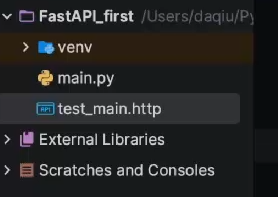

Inside the main.py is the beginning of the whole FastAPI

In [ ]:
from fastapi import FastAPI


# Create an object for fastapi application
app = FastAPI()

@app.get("/")
async def root():
    return {"message":"Hello FastAPI"}

@app.get("/hello/{name}")
async def say_hello(name:str):
    return {"message": f"Hello {name}"}

The FastAPI app should have a main file, then firstly always create an object of this app

**In the end**, in the direcrory of `main.py` use the `uvicon main:[object name of the FastAPI] --reload`, the reload is making sure while the code has been changed, the server will restart automatically

## 3. Routing

Routing is the connection between URL and the excute function, if we visit one URL, which code will be running.

In FASTAPI, routing uses decoration to implement, which is the `@`

In [ ]:
@app.get("/")
async def root():
    return {"message":"Hello FastAPI"}

This bar of code means: 

In the FastAPI application, which object name is app, while user doing get in the page `default ip/`, the server will running the function root()

## 4.Parameters

Client can sending parameters via the API

There always been these 3 kinds of parameters

|Name|Location|Action|Usage|
|:---|:---:|:---:|---:|
|`Route Parameters`| Part of the URL eg: /book/{id}| GET | Using for localize specific resource
|`Query Parameters`| After the URL eg: **URL**k1=v1&k2=v2 | GET | Sort resources by some rule
|`Request Body` | Http request's request body | PUT/POST | Sending resources to Server

### Route Parameters

**Type annotation**: Inside the Route Parameters, there is a feature called type annotation, it helps the developer to find out the type of paprameters, but do not have the force to make developer can only use this kind of parameter type, but the FastAPI provides powerful type annotaion which forces the API can only receive this kind of parameter.

In [ ]:
@app.get("/book/{id}")

async def get_book_id(id : int):
    return {"id": id, "title": f"This is book {id}"}

The `id:int` is the type annotation

**Path function**: The Path function provides more method to control the input style

In [ ]:
# Import the Path
from fastapi import Path

# Implement a Route parameter example
@app.get("/book/{id}")

async def get_book_id(id:int = Path(..., gt=0, le=100, description="The id of book, which from 1 to 100")):
    return {"id": id, "title": f"This is book {id}"}

Usually using `=` to connect the type annotations, the table below shows frequently used parameters

| Path Parameter | Description |
|---|---|
| `...` | Required |
| `gt` / `ge` | Greater than / Greater than or equal to |
| `lt` / `le` | Less than / Less than or equal to |
| `description` | Description |
| `min_length` / `max_length` | Length limits |

### Query Parameters

The Query parameters **no need** to be specified like the route parameters, it can be used by calling parameters in function

In [ ]:
# Requirements: Seeking the news, and distinct the news by pages. Has two Query parameters: skip: The number of skipping pages, 
# limit: The number of returning record.
@app.get("/news/news_list")
async def get_news_list(skip:int, limit:int=10):
    return {"skip":skip, "limit":limit}

The skip and the limit are query parameters. 

**Query Function**: Same to the Route parameters, the Query parameters has same kind of function, called **Query**, provides more style to control the Query.

In [ ]:
from fastapi import Query


@app.get("/news/news_list")
async def get_news_list(skip:int = Query(..., description="The number of skipped pages", le=400), 
                        limit:int = Query(10, description="The number of returning record")):
    return {"skip":skip, "limit":limit}

The Query function can set default parameters by giving the default value in the beginning of the Query function

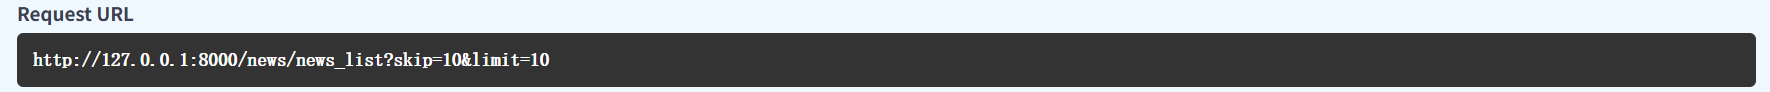

Inside after the **?** is the Query parameters

### Request Body

In the HTTP protocol, a complete request consists of three parts:

1. **Request Line**: contains the method, URL, and protocol version.

2. **Request Headers**: contain metadata information, such as `Content-Type`, `Authorization`, etc.

3. **Request Body**: contains the actual data content to be sent.

To use the Request body, need to import the class **BaseModel** from **pydantic**, then create a class which extends **Basemodel** to set a request body.

In [ ]:
from pydantic import BaseModel


class User(BaseModel):
    username : str
    password : str

The class User is a Request body, to use the request body as a parameter, using the type annotation to call the class `User` behind the `:`

In [ ]:
# Create a Request body then combine it with a route
class User(BaseModel):
    username : str
    password : str
    
@app.post("/request")
async def start_request(user:User):
    return User

Same as the Route parameter and the Query parameter, the Request body has the type function, which name is **Field**

**Field Function**: Same parameters as before, gives the request body more options, use `=` to connect with type annotation in Request body class. 

In [ ]:
class User(BaseModel):
    username : str = Field(..., min_length=2, description="Name of the user")
    password : str = Field(min_length=5, max_length=20, description="Your password")
    
@app.post("/request")
async def start_request(user:User):
    return user

## 5. Response Type

### JSON

By default, FastAPI automatically converts the Python objects returned by path operation functions, such as dictionaries, lists, and Pydantic models, into a JSON-compatible format through `jsonable_encoder`, and then wraps them in a `JSONResponse`.

This removes the need for manual serialization, allowing developers to focus more on business logic.

If non-JSON data needs to be returned, such as HTML or file streams, FastAPI provides various response types for returning different kinds of data.

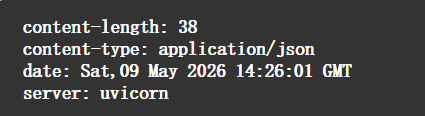

The second line claims that the type is json

### Two ways to specify the response type

In FastAPI, if the response type is **clearly or static**, always using the **decorator** to set the response type, if the response type is **not clear** or the response type need to be changed based conditions, always **returning the specific response object**.

#### Decorator

1. Import the responses from library fastapi, then import the specific type want to use

2. add it inside the decorator by the paramter `response_class`

In [ ]:
from fastapi.responses import HTMLResponse


@app.get("/HTML", response_class=HTMLResponse)
async def html():
    return "<h1>Hello HTML</h1>"

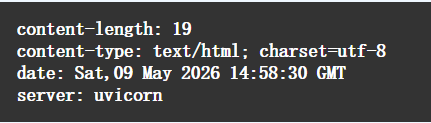

#### Directly Return the Response Object

1. Import the responses from library fastapi, then import the specific type want to use

2. Use the type to normalize in the returning

In [ ]:
from fastapi.responses import FileResponse


# A interface to response the File type
@app.get("/file")
async def get_file():
    file_path= "./Resources/Genshen.jpg"
    return FileResponse(path=file_path)

#### Self-Definding Response Type

**Self-Definding Response Type only works using the Json Response**

`response_model` is a key parameter of path operation decorators, such as `@app.get` or `@app.post`.

It uses a Pydantic model to strictly define and constrain the output format of an API endpoint.

This mechanism not only provides automatic data validation and serialization, but also serves as the first line of defense for ensuring data security.

1. from the `pydantic` import `Basemodel`

2. Create a class extends the `Basemodel`, then set all parameters inside this class

3. In decorator, uses the `response_model` to specify the Self-Definding Response type

In [ ]:
from pydantic import BaseModel


# News interface, need id, title, content
class News(BaseModel):
    id:int
    title:str
    content:str
    
@app.get("/news/{id}", response_model=News)
async def get_news(id:int):
    return {"id":id, "title":"Nice Book", "content":"Coding"}

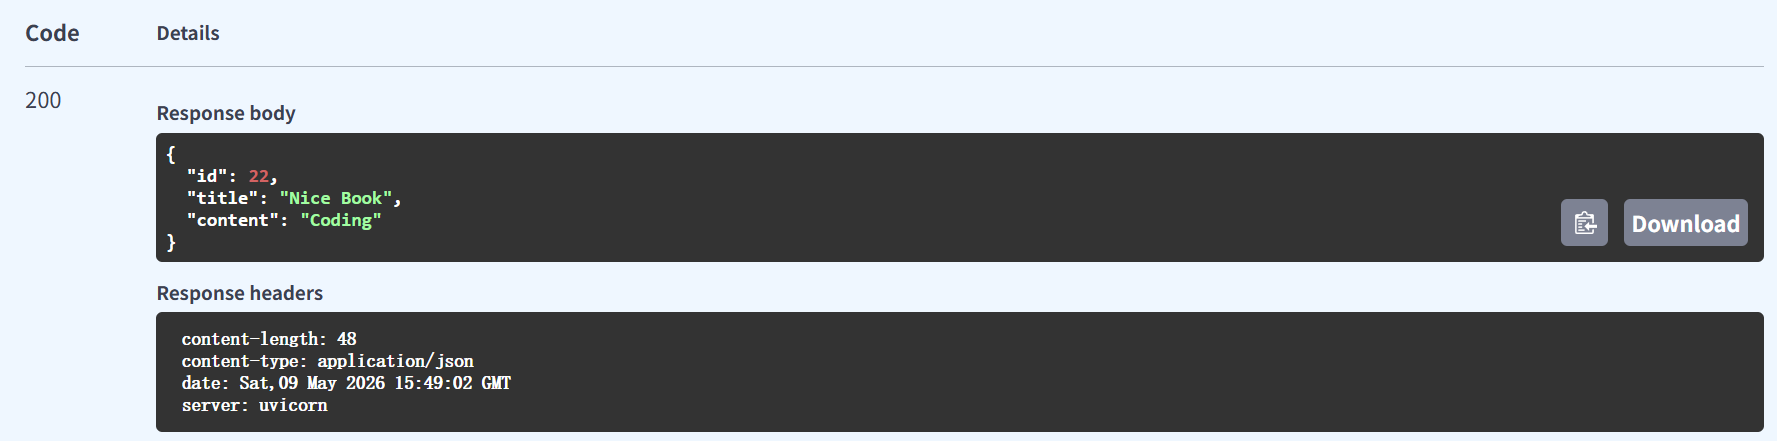

The Self-Definding type will forces the return follows the type inside, or it will has internal error

In [ ]:
from pydantic import BaseModel


# News interface, need id, title, content
class News(BaseModel):
    id:int
    title:str
    content:str
    
@app.get("/news/{id}", response_model=News)
async def get_news(id:int):
    return {"id":id, "title":"Nice Book"}

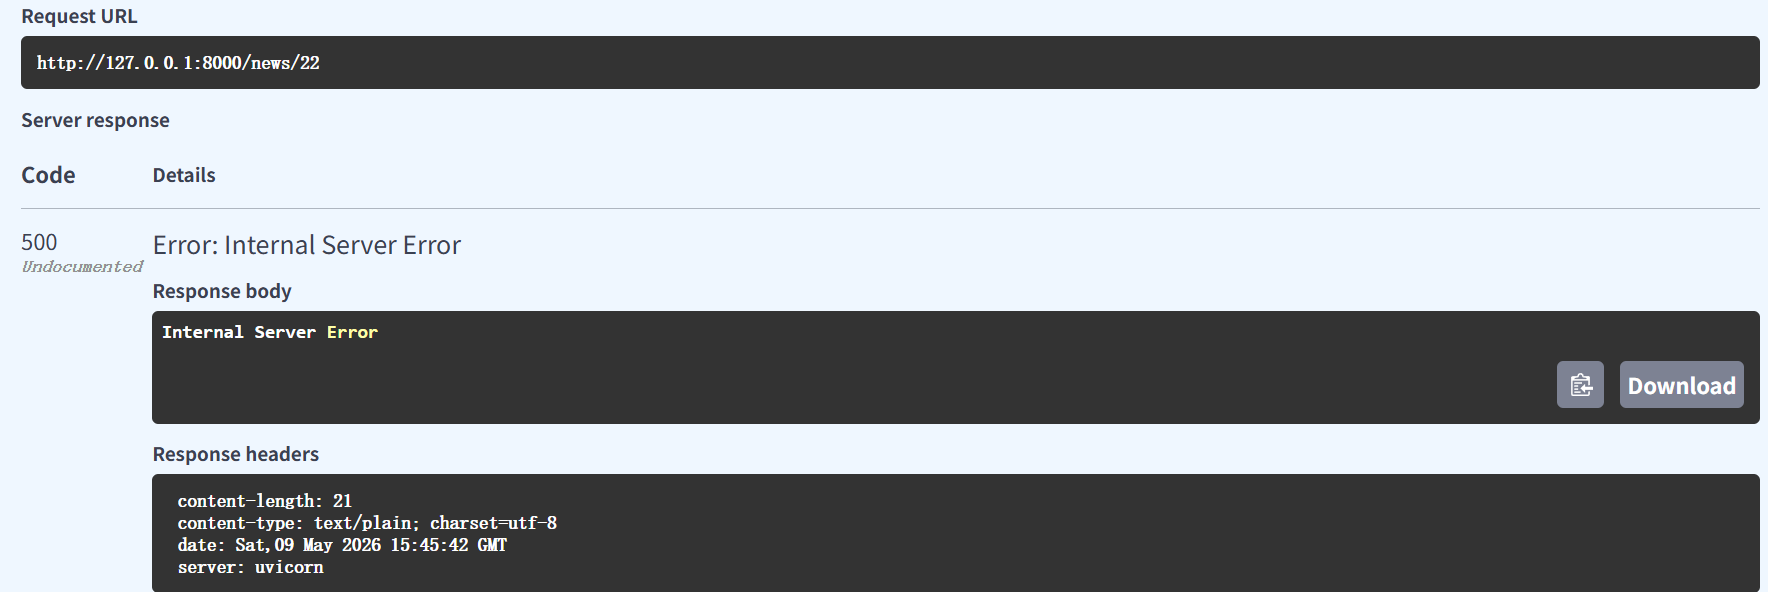

## 6. Exceptions Handling

For errors caused by the client side, such as `4xx` errors including resource not found or authentication failure, `fastapi.HTTPException` should be used to interrupt the normal processing flow and return a standard error response.

1. Import the HTTPException from the fastapi

2. Using keyword `raise` to cause the exception in some condition

3. After the raise needs specify parameters inside the HTTPException.

In [ ]:
from fastapi import HTTPException


# Using the HTTPException
@app.get("/user/{id}")
async def get_user_by_id(id:int):
    id_list = [1, 2, 3, 4, 5]
    if id not in id_list:
        raise HTTPException(status_code=404, detail="No this id exist")
    return {"id": id}